# MobileNetV2 Training (Standardized)

Standardized training pipeline matching DenseNet121 reference.

In [3]:
!pip install -q split-folders timm grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 110.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import timm
import cv2
import numpy as np
import shutil
import glob
import splitfolders
import matplotlib.pyplot as plt
from PIL import Image
import copy
import time
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import random
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [7]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os

# Check if running in Colab
if IN_COLAB:
    # Mount the drive if it's not already mounted
    if not os.path.exists('/content/drive'):
        print("Mounting Google Drive...")
        drive.mount('/content/drive')
    else:
        print("Google Drive is already mounted.")
else:
    print("Not running in Colab.")

Mounting Google Drive...
Mounted at /content/drive


In [12]:
import zipfile
import os

# Updated path to point to the correct Google Drive location
zip_path = "/content/drive/MyDrive/Colab Notebooks/bintang/Combined_dataset.zip"
extract_dir = "unzipped_dataset"

# Create extraction directory if it doesn't exist
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

if os.path.exists(zip_path):
    print(f"Unzipping {zip_path} to {extract_dir}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Unzipping complete.")
else:
    print(f"File not found at: {zip_path}")
    print("Please verify the file path in your Google Drive.")

Unzipping /content/drive/MyDrive/Colab Notebooks/bintang/Combined_dataset.zip to unzipped_dataset...
Unzipping complete.


In [14]:
import os
import shutil
import splitfolders

# Base directory where zip was extracted
base_extract_dir = "unzipped_dataset"
output_folder = "dataset_split"

# Function to find the actual dataset root (folder containing class subfolders)
def find_dataset_root(base_dir):
    for root, dirs, files in os.walk(base_dir):
        # Check if this directory contains subdirectories that look like classes (and have images)
        if len(dirs) > 0:
            # Simple heuristic: check if subfolders contain images
            for d in dirs:
                subpath = os.path.join(root, d)
                if any(f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')) for f in os.listdir(subpath)):
                    return root
    return base_dir

# Find the correct input folder
input_folder = find_dataset_root(base_extract_dir)
print(f"Detected dataset root at: {input_folder}")

# Check contents of the detected root
if os.path.exists(input_folder):
    print("Classes found:", os.listdir(input_folder))
else:
    print(f"Directory not found: {input_folder}")

# Prepare output directory
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

# Run splitfolders
if input_folder and os.path.exists(input_folder) and len(os.listdir(input_folder)) > 0:
    print("Splitting dataset...")
    splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.7, .15, .15), group_prefix=None)
    print("Dataset split complete.")
else:
    print("Error: Input folder is empty or invalid. Please check the unzip step.")

Detected dataset root at: unzipped_dataset/Combined_dataset
Classes found: ['benign', 'normal', 'malignant']
Splitting dataset...


Copying files: 1030 files [00:00, 3391.60 files/s]

Dataset split complete.


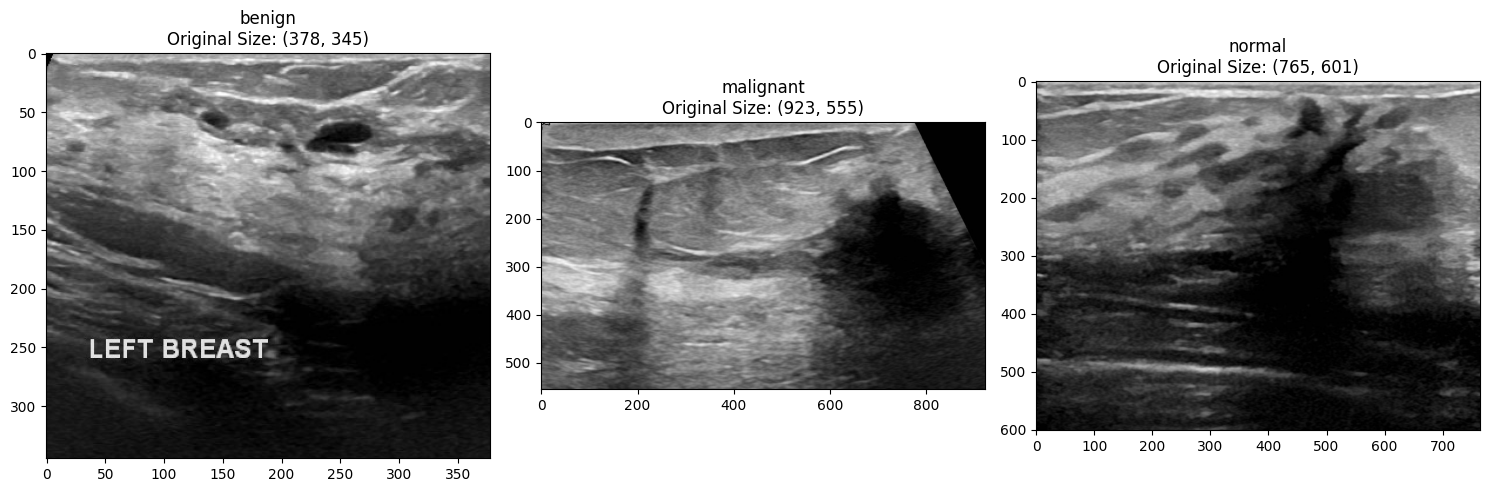

In [15]:
def show_raw_images(dataset_path, num_images=3):
    classes = ['benign', 'malignant', 'normal']
    plt.figure(figsize=(15, 5))
    for i, cls in enumerate(classes):
        class_folder = os.path.join(dataset_path, 'train', cls)
        if os.path.exists(class_folder) and len(os.listdir(class_folder)) > 0:
            random_img = random.choice(os.listdir(class_folder))
            img_path = os.path.join(class_folder, random_img)
            img = Image.open(img_path)
            plt.subplot(1, 3, i+1)
            plt.imshow(img, cmap='gray')
            plt.title(f"{cls}\nOriginal Size: {img.size}")
            plt.axis('on')
    plt.tight_layout()
    plt.show()

show_raw_images(output_folder)

In [16]:
class UltrasoundEnhancement(object):
    def __init__(self, apply_clahe=True, apply_denoise=True):
        self.apply_clahe = apply_clahe
        self.apply_denoise = apply_denoise

    def __call__(self, img):
        img_np = np.array(img.convert('L'))

        if self.apply_denoise:
            img_np = cv2.medianBlur(img_np, 5)

        if self.apply_clahe:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            img_np = clahe.apply(img_np)

        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(img_rgb)

print("UltrasoundEnhancement class created.")

UltrasoundEnhancement class created.


In [17]:
data_transforms = {
    'train': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

data_dir = output_folder
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=2)
               for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Dataset Sizes: {dataset_sizes}")

Classes: ['benign', 'malignant', 'normal']
Dataset Sizes: {'train': 719, 'val': 153, 'test': 158}


In [18]:
def get_model(model_name, num_classes):
    print(f"Creating model: {model_name}...")
    model = timm.create_model(model_name, pretrained=True)

    # Replace classifier head based on model structure
    if 'efficientnet' in model_name or 'mobilenet' in model_name:
        if hasattr(model, 'classifier'):
            in_features = model.classifier.in_features
            model.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, num_classes)
            )
        elif hasattr(model, 'fc'):
            in_features = model.fc.in_features
            model.fc = nn.Sequential(
                nn.Dropout(0.2),
                nn.Linear(in_features, num_classes)
            )

    return model.to(device)

# Instantiate MobileNetV2
model = get_model('mobilenetv2_100', len(class_names))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 20

Creating model: mobilenetv2_100...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

In [19]:
def train_model(model, criterion, optimizer, num_epochs=20):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

In [20]:
model, history = train_model(model, criterion, optimizer, num_epochs=num_epochs)

# Save model
torch.save(model.state_dict(), 'mobilenetv2_ultrasound.pth')
print("Model saved as mobilenetv2_ultrasound.pth")

Epoch 1/20
----------
train Loss: 0.9753 Acc: 0.5382
val Loss: 0.9155 Acc: 0.6209

Epoch 2/20
----------
train Loss: 0.8292 Acc: 0.6495
val Loss: 0.8015 Acc: 0.6667

Epoch 3/20
----------
train Loss: 0.7427 Acc: 0.6495
val Loss: 0.7390 Acc: 0.6667

Epoch 4/20
----------
train Loss: 0.6420 Acc: 0.7274
val Loss: 0.6884 Acc: 0.6797

Epoch 5/20
----------
train Loss: 0.5812 Acc: 0.7622
val Loss: 0.6269 Acc: 0.7124

Epoch 6/20
----------
train Loss: 0.5076 Acc: 0.7955
val Loss: 0.5942 Acc: 0.7582

Epoch 7/20
----------
train Loss: 0.4705 Acc: 0.8081
val Loss: 0.5706 Acc: 0.7647

Epoch 8/20
----------
train Loss: 0.4469 Acc: 0.8331
val Loss: 0.5481 Acc: 0.7647

Epoch 9/20
----------
train Loss: 0.4275 Acc: 0.8192
val Loss: 0.5529 Acc: 0.7712

Epoch 10/20
----------
train Loss: 0.3689 Acc: 0.8637
val Loss: 0.5252 Acc: 0.7778

Epoch 11/20
----------
train Loss: 0.3282 Acc: 0.8720
val Loss: 0.4805 Acc: 0.7974

Epoch 12/20
----------
train Loss: 0.3340 Acc: 0.8720
val Loss: 0.4618 Acc: 0.8039

E

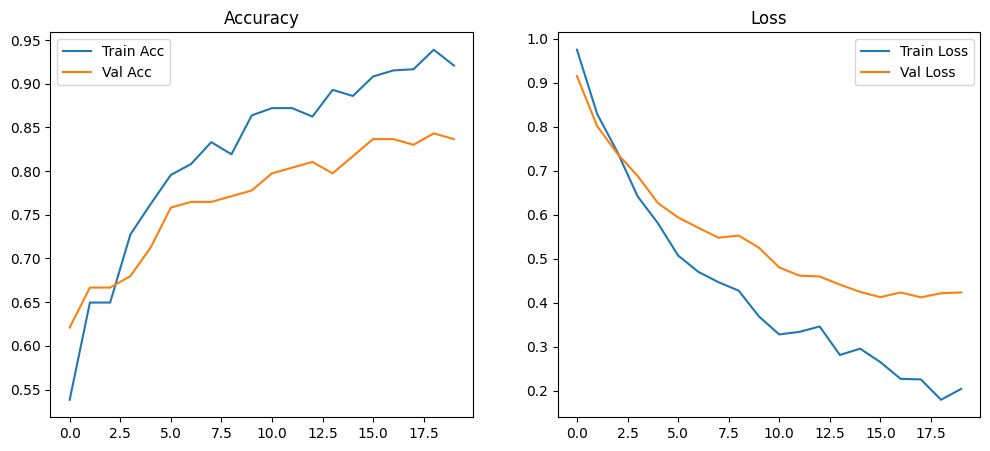

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

Evaluating on Test Set...
Classification Report:
              precision    recall  f1-score   support

      benign       0.83      0.91      0.87        82
   malignant       0.92      0.80      0.85        55
      normal       0.85      0.81      0.83        21

    accuracy                           0.86       158
   macro avg       0.87      0.84      0.85       158
weighted avg       0.86      0.86      0.86       158



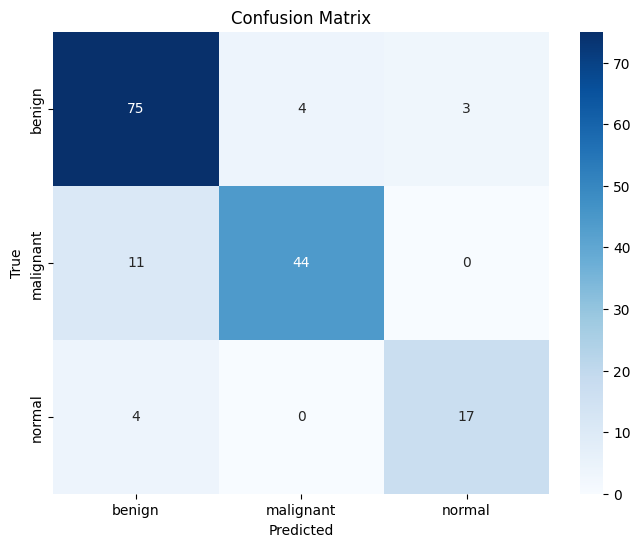

In [22]:
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

print("Evaluating on Test Set...")
evaluate_model(model, dataloaders['test'])

Showing GradCAM results on Test Set...


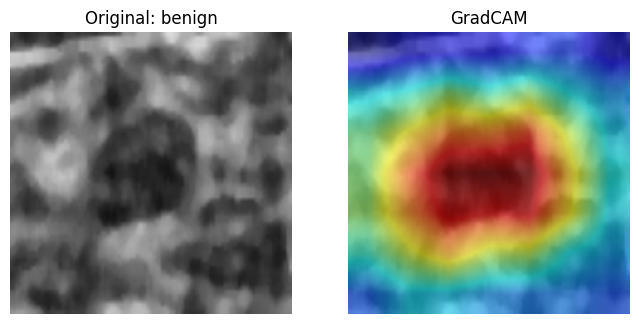

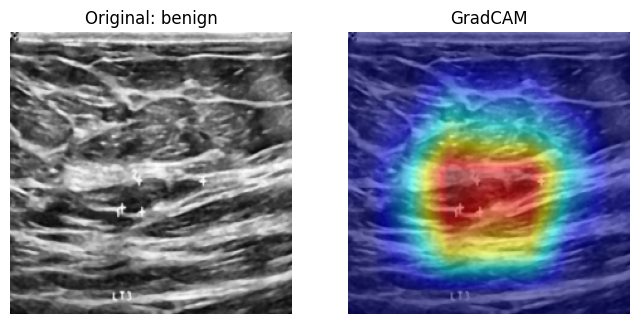

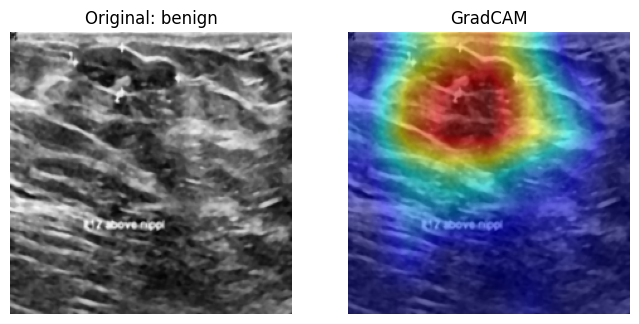

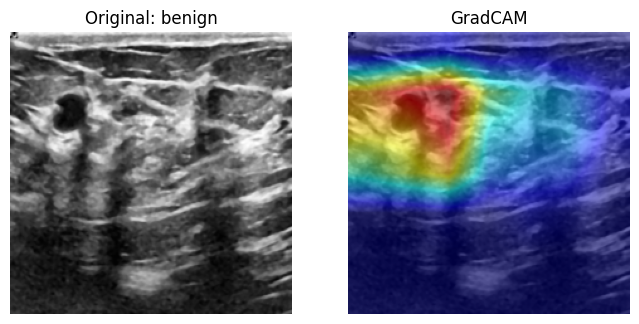

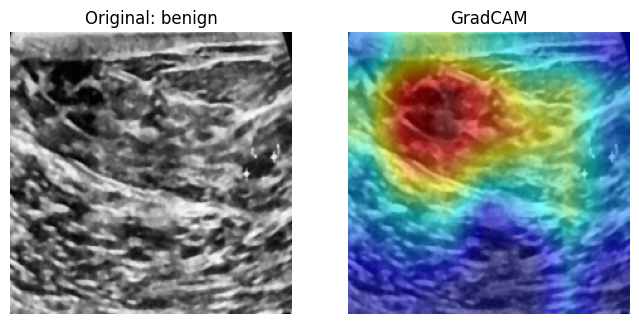

In [23]:
# GradCAM Visualization
model.eval()

# MobileNetV2 target layer: conv_head
target_layers = [model.conv_head]

cam = GradCAM(model=model, target_layers=target_layers)

def show_gradcam(dataset, num_images=5):
    indices = random.sample(range(len(dataset)), num_images)

    for i in indices:
        img_tensor, label = dataset[i]
        img_tensor = img_tensor.unsqueeze(0).to(device)

        # Generate CAM
        targets = [ClassifierOutputTarget(label)]
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]

        # Prepare original image for visualization
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img_np)
        plt.title(f"Original: {class_names[label]}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(visualization)
        plt.title("GradCAM")
        plt.axis('off')
        plt.show()

print("Showing GradCAM results on Test Set...")
show_gradcam(image_datasets['test'])

In [ ]:
model_name = "MobileNetV2"
print(f"Visualizing Grad-CAM for {len(class_names)} classes...")

def visualize_gradcam_per_class(model, dataloader, class_names, target_layers, model_name, device):
    model.eval()
    inverse_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    # Standard gradcam from pytorch_grad_cam
    cam = GradCAM(model=model, target_layers=target_layers)

    dataset = dataloader.dataset
    
    class_indices = {}
    # Try to find indices based on targets attribute (common in ImageFolder)
    if hasattr(dataset, 'targets'):
        targets = np.array(dataset.targets)
        for class_idx in range(len(class_names)):
             indices = np.where(targets == class_idx)[0]
             if len(indices) > 0:
                 class_indices[class_names[class_idx]] = indices[0]
    
    if not class_indices:
         print("Could not directly access dataset targets. Showing random images instead.")
         return

    plt.figure(figsize=(12, 4 * len(class_names)))
    
    for i, class_name in enumerate(class_names):
        if class_name in class_indices:
            idx = class_indices[class_name]
            image, label = dataset[idx]
            # Un-normalize
            input_tensor = image.unsqueeze(0).to(device)
            grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(label)])[0, :]
            
            img_display = inverse_normalize(image).permute(1, 2, 0).cpu().numpy()
            img_display = np.clip(img_display, 0, 1)
            visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)
            
            plt.subplot(len(class_names), 2, 2 * i + 1)
            plt.imshow(img_display)
            plt.title(f"{model_name} - Original - {class_name}")
            plt.axis('off')
            
            plt.subplot(len(class_names), 2, 2 * i + 2)
            plt.imshow(visualization)
            plt.title(f"{model_name} - GradCAM - {class_name}")
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

visualize_gradcam_per_class(model, dataloaders['test'], class_names, target_layers, "MobileNetV2", device)